## Pranay's Contribution

LLM Prompts:
- Explain me everything about GAN and types of GANs
- now tell me indetail about cGAN
- i have a dataset of food,drink,inside and outside images how to build a cGAN model
- how gernerator descriminator work in the cGAN
- what is the best image size to train faster in cGAN
- how many epochs is better can you tell according to my inputs given?

In [1]:
from google.colab import files
uploaded = files.upload()


In [2]:
!unzip -q wgan_ready.zip


In [5]:
import os

data_path = "/content/wgan_ready"
all_files = os.listdir(data_path)

print(f"Total files found: {len(all_files)}")
print("Sample files:", all_files[:5])


Total files found: 5
Sample files: ['drink', 'inside', '.DS_Store', 'food', 'outside']


In [6]:
import os

data_path = "/content/wgan_ready"
labels = ['food', 'drink', 'inside', 'outside']

for label in labels:
    folder_path = os.path.join(data_path, label)
    if os.path.isdir(folder_path):
        num_images = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        print(f"{label}: {num_images} images")


food: 15000 images
drink: 15000 images
inside: 15000 images
outside: 15000 images


In [7]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
import torch
import os

class YelpImageFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.label_map = {'food': 0, 'drink': 1, 'inside': 2, 'outside': 3}

        for label_name in self.label_map:
            label_folder = os.path.join(root_dir, label_name)
            for fname in os.listdir(label_folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(label_folder, fname), self.label_map[label_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label)

# Define transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # Normalize to [-1, 1] for GAN
])

# Instantiate the dataset
dataset = YelpImageFolderDataset("/content/wgan_ready", transform=transform)


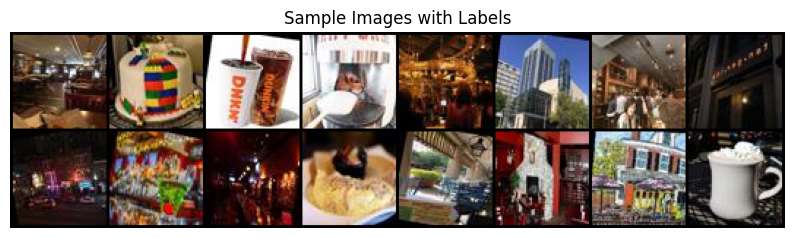

Labels in this batch: [2, 2, 1, 0, 2, 3, 2, 3, 3, 1, 2, 0, 3, 2, 3, 1]


In [8]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Get one batch of images
images, labels = next(iter(dataloader))

# Denormalize images (from [-1,1] back to [0,1] for viewing)
images = images * 0.5 + 0.5

# Plot the batch
plt.figure(figsize=(10, 5))
plt.axis("off")
plt.title("Sample Images with Labels")
plt.imshow(vutils.make_grid(images, nrow=8).permute(1, 2, 0))
plt.show()

# Print labels
print("Labels in this batch:", labels.tolist())


In [23]:
import torch
import torch.nn as nn

# ---------- Generator ----------
class Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=4, img_channels=3, feat=64):
        super().__init__()
        # one‑hot–style embedding for the labels
        self.label_emb = nn.Embedding(num_classes, num_classes)

        # DCGAN‑style upsampling blocks
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim + num_classes, feat * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feat * 8), nn.ReLU(True),

            nn.ConvTranspose2d(feat * 8, feat * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 4), nn.ReLU(True),

            nn.ConvTranspose2d(feat * 4, feat * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 2), nn.ReLU(True),

            nn.ConvTranspose2d(feat * 2, feat, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat), nn.ReLU(True),

            nn.ConvTranspose2d(feat, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()                                  # output in [-1, 1]
        )

    def forward(self, noise, labels):
        label_onehot = self.label_emb(labels)          # (B, 4)
        x = torch.cat([noise, label_onehot], dim=1)    # (B, z_dim+4)
        x = x.unsqueeze(2).unsqueeze(3)                # (B, z_dim+4, 1, 1)
        return self.net(x)                             # (B, 3, 64, 64)

# ----- quick sanity check -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 100
G = Generator(z_dim=z_dim).to(device)

test_noise  = torch.randn(8, z_dim, device=device)
test_labels = torch.randint(0, 4, (8,), device=device)
print("Generator output shape:", G(test_noise, test_labels).shape)  # expect (8, 3, 64, 64)


Generator output shape: torch.Size([8, 3, 64, 64])


In [24]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=4, img_channels=3, feat=64):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.net = nn.Sequential(
            nn.Conv2d(img_channels + num_classes, feat, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feat, feat * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feat * 2, feat * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feat * 4, feat * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feat * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        label_onehot = self.label_emb(labels)
        label_map = label_onehot.unsqueeze(2).unsqueeze(3).expand(-1, -1, imgs.size(2), imgs.size(3))
        x = torch.cat([imgs, label_map], dim=1)  # Concatenate along channels
        return self.net(x).view(-1)


In [25]:
D = Discriminator().to(device)
fake_imgs = G(test_noise, test_labels)
output = D(fake_imgs, test_labels)
print("Discriminator output shape:", output.shape)  # Expect: (8,)


Discriminator output shape: torch.Size([8])


#### testing the model while running just 5 epochs

In [12]:
import torch.optim as optim

# Hyperparameters
lr = 2e-4
epochs = 5
batch_size = 64
z_dim = 100

# Instantiate models & loss
G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# Create DataLoader again just in case
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(1, epochs+1):
    for real_imgs, labels in dataloader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        # Real and fake labels
        real = torch.ones(batch_size, device=device)
        fake = torch.zeros(batch_size, device=device)

        ### Train Discriminator ###
        noise = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(noise, labels)

        real_loss = criterion(D(real_imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        ### Train Generator ###
        noise = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(noise, labels)
        g_loss = criterion(D(fake_imgs, labels), real)  # try to fool D

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch [1/5] | D Loss: 0.4612 | G Loss: 1.9186
Epoch [2/5] | D Loss: 0.2166 | G Loss: 4.0335
Epoch [3/5] | D Loss: 0.1364 | G Loss: 3.4523
Epoch [4/5] | D Loss: 0.0090 | G Loss: 5.4790
Epoch [5/5] | D Loss: 0.0285 | G Loss: 5.0802


Saved: generated_cgan/food.png
Saved: generated_cgan/drink.png
Saved: generated_cgan/inside.png
Saved: generated_cgan/outside.png
Saved: generated_cgan/random.png


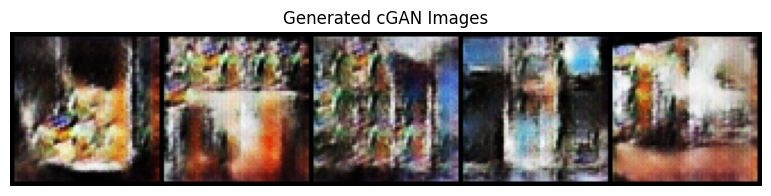

Generator(
  (label_emb): Embedding(4, 4)
  (net): Sequential(
    (0): ConvTranspose2d(104, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=

In [13]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from torchvision.utils import save_image
import os

# Set Generator to eval mode
G.eval()

# Labels: food, drink, inside, outside, random
label_names = ['food', 'drink', 'inside', 'outside']
labels = torch.tensor([0, 1, 2, 3], device=device)

# Add a 5th random label
labels = torch.cat([labels, torch.randint(0, 4, (1,), device=device)])

# Generate noise & fake images
z = torch.randn(5, z_dim, device=device)
with torch.no_grad():
    fake_imgs = G(z, labels)

# De-normalize
fake_imgs = fake_imgs * 0.5 + 0.5

# Create output directory
os.makedirs("generated_cgan", exist_ok=True)

# Save each image
for i, img in enumerate(fake_imgs):
    save_path = f"generated_cgan/{label_names[labels[i].item()] if i < 4 else 'random'}.png"
    save_image(img, save_path)
    print(f"Saved: {save_path}")

# Display all 5
plt.figure(figsize=(10,2))
plt.axis("off")
plt.title("Generated cGAN Images")
plt.imshow(vutils.make_grid(fake_imgs, nrow=5).permute(1,2,0).cpu())
plt.show()

# Back to train mode
G.train()


as the model was running fine lest increase the no of epochs

In [14]:
import torch, os, torch.optim as optim

# ---------------- hyper‑params ----------------
lr         = 2e-4
epochs     = 25
batch_size = 128
z_dim      = 100

# ---------------- data / models --------------
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)

criterion   = nn.BCELoss()
opt_G       = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D       = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# --------- checkpoint helpers ----------
os.makedirs("checkpoints", exist_ok=True)
best_g_loss = float("inf")          # lower is better

# ---------------- training loop -------------
for epoch in range(1, epochs + 1):
    for real, labels in dataloader:
        real, labels = real.to(device), labels.to(device)
        bsz         = real.size(0)
        real_y      = torch.ones (bsz, device=device)
        fake_y      = torch.zeros(bsz, device=device)

        # ---- Train Discriminator ----
        noise      = torch.randn(bsz, z_dim, device=device)
        fake_imgs  = G(noise, labels)

        d_real_loss = criterion(D(real, labels), real_y)
        d_fake_loss = criterion(D(fake_imgs.detach(), labels), fake_y)
        d_loss      = (d_real_loss + d_fake_loss) / 2

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # ---- Train Generator ----
        noise      = torch.randn(bsz, z_dim, device=device)
        fake_imgs  = G(noise, labels)
        g_loss     = criterion(D(fake_imgs, labels), real_y)  # wants D to think "real"

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    # -------- end‑of‑epoch logging ----------
    print(f"Epoch [{epoch:2}/{epochs}] | D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")
    # ---- END‑OF‑TRAINING SAVE ---------------------------------
    # put this *after* the for‑epoch loop finishes
    torch.save(G.state_dict(), "checkpoints/last_generator.pth")
    torch.save(D.state_dict(), "checkpoints/last_discriminator.pth")
    print("Saved final epoch model as last_generator.pth / last_discriminator.pth")

# ---------------- download from Colab ---------------
from google.colab import files
files.download("checkpoints/best_generator.pth")        # triggers browser download

import torch, torchvision.utils as vutils, matplotlib.pyplot as plt
G.eval()
labels = torch.tensor([0,1,2,3], device=device)          # food, drink, inside, outside
z      = torch.randn(4, 100, device=device)
with torch.no_grad():
    fakes = G(z, labels) * 0.5 + 0.5                     # denorm to [0,1]
plt.figure(figsize=(8,2)); plt.axis("off")
plt.imshow(vutils.make_grid(fakes, nrow=4).permute(1,2,0).cpu())
plt.show()
G.train()


Epoch [ 1/50] | D_loss: 0.5035 | G_loss: 3.8876
  ↳ New best G_loss!  Saved checkpoints at epoch 1.
Epoch [ 2/50] | D_loss: 0.4467 | G_loss: 3.4044
  ↳ New best G_loss!  Saved checkpoints at epoch 2.
Epoch [ 3/50] | D_loss: 0.4070 | G_loss: 1.6056
  ↳ New best G_loss!  Saved checkpoints at epoch 3.
Epoch [ 4/50] | D_loss: 0.2156 | G_loss: 5.1257
Epoch [ 5/50] | D_loss: 0.0532 | G_loss: 3.6244
Epoch [ 6/50] | D_loss: 0.0908 | G_loss: 3.9555
Epoch [ 7/50] | D_loss: 0.1272 | G_loss: 2.9443
Epoch [ 8/50] | D_loss: 0.0535 | G_loss: 2.9264
Epoch [ 9/50] | D_loss: 0.0098 | G_loss: 5.4381
Epoch [10/50] | D_loss: 0.0276 | G_loss: 5.4474
Epoch [11/50] | D_loss: 0.0444 | G_loss: 4.3948
Epoch [12/50] | D_loss: 0.0217 | G_loss: 6.1942
Epoch [13/50] | D_loss: 0.0651 | G_loss: 7.0138
Epoch [14/50] | D_loss: 0.0090 | G_loss: 4.3432
Epoch [15/50] | D_loss: 0.0120 | G_loss: 7.2813
Epoch [16/50] | D_loss: 0.0091 | G_loss: 6.6592
Epoch [17/50] | D_loss: 0.0291 | G_loss: 7.0450
Epoch [18/50] | D_loss: 0.06

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

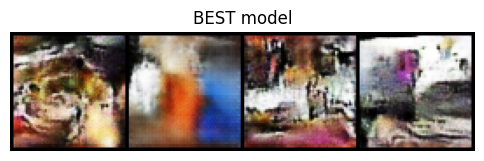

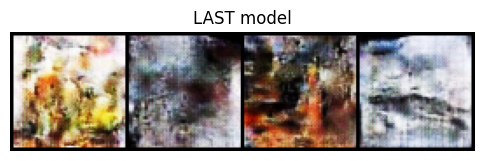

In [7]:
# common setup
import torch, torchvision.utils as vutils, matplotlib.pyplot as plt
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim    = 100
labels   = torch.tensor([0,1,2,3], device=device)   # food, drink, inside, outside
noise    = torch.randn(4, z_dim, device=device)     # fixed seed for fair comparison

# helper to generate one 2×2 grid
def sample_grid(G, title):
    G.eval()
    with torch.no_grad():
        imgs = G(noise, labels) * 0.5 + 0.5          # denorm
    plt.figure(figsize=(6,2)); plt.axis("off"); plt.title(title)
    plt.imshow(vutils.make_grid(imgs, nrow=4).permute(1,2,0).cpu())
    plt.show()
    G.train()

# load & display best model
G_best = Generator(z_dim=z_dim).to(device)
G_best.load_state_dict(torch.load("checkpoints/best_generator.pth"))
sample_grid(G_best, "BEST model")

# load & display last model
G_last = Generator(z_dim=z_dim).to(device)
G_last.load_state_dict(torch.load("checkpoints/current_generator.pth"))
sample_grid(G_last, "LAST model")


Above is the outputs of the cGAN after running the 25 ephochs and comparing with best model sofar inthe epochs and the last model.. and saving the best model.

In [11]:

# --------------- 2. imports & dataset setup --------------
import torch, os
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 100

# --- your dataset class (same as before) ---
class YelpImageFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.label_map = {'food': 0, 'drink': 1, 'inside': 2, 'outside': 3}
        for label_name in self.label_map:
            folder_path = os.path.join(root_dir, label_name)
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(folder_path, fname), self.label_map[label_name]))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label)

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Reload dataset and dataloader
dataset = YelpImageFolderDataset("/content/wgan_ready", transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# --------------- 3. helper functions ---------------------
def to_uint8(imgs):
    return (imgs * 127.5 + 127.5).clamp(0, 255).to(torch.uint8)

def make_metrics(generator, N_BATCH=4, BATCH=128):
    fid = FrechetInceptionDistance(normalize=False).to(device)
    isc = InceptionScore().to(device)

    for _ in range(N_BATCH):
        z = torch.randn(BATCH, z_dim, device=device)
        lbl = torch.randint(0, 4, (BATCH,), device=device)
        with torch.no_grad():
            fakes = generator(z, lbl)
        fid.update(to_uint8(fakes), real=False)
        isc.update(to_uint8(fakes))

    real_iter = iter(dataloader)
    for _ in range(N_BATCH):
        reals, _ = next(real_iter)
        fid.update(to_uint8(reals.to(device)), real=True)

    return fid.compute().item(), isc.compute()[0].item()

# --------------- 4. reload models & run metrics ----------
G_best = Generator(z_dim=z_dim).to(device)
G_best.load_state_dict(torch.load("checkpoints/best_generator.pth"))
G_best.eval()

G_last = Generator(z_dim=z_dim).to(device)
G_last.load_state_dict(torch.load("checkpoints/current_generator.pth"))
G_last.eval()

# Run & print scores
print("Evaluating BEST checkpoint …")
fid_best, is_best = make_metrics(G_best)
print(f"BEST  →  FID: {fid_best:.2f}   IS: {is_best:.2f}")

print("\nEvaluating LAST checkpoint …")
fid_last, is_last = make_metrics(G_last)
print(f"LAST  → FID: {fid_last:.2f}   IS: {is_last:.2f}")


Evaluating BEST checkpoint …
BEST  →  FID: 306.14   IS: 2.49

Evaluating LAST checkpoint …
LAST  → FID: 352.42   IS: 2.00


After evaluting the FID (frechet inception distance)  and IS (inception Score) scores.. 
- The BEST model got FID 306.14 and IS 2.49, which is better than the LAST model with FID 352.42 and IS 2.00, so it makes more real-looking images.

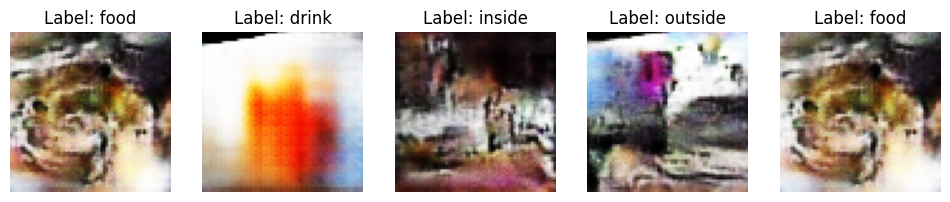

In [13]:
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import os

# Ensure G_best is loaded and in eval mode
G_best.eval()

# Set labels you want images for (0: food, 1: drink, 2: inside, 3: outside)
labels = torch.tensor([0, 1, 2, 3, 0], device=device)  # Adding two 'food' labels for variety
z = torch.randn(len(labels), z_dim, device=device)

# Generate images with G_best
with torch.no_grad():
    generated_imgs = G_best(z, labels)

# Denormalize the images from [-1, 1] to [0, 1]
generated_imgs = (generated_imgs + 1) / 2

# Save directory
os.makedirs("generated_samples", exist_ok=True)

# Save each image separately (optional)
for i, img in enumerate(generated_imgs):
    vutils.save_image(img, f"generated_samples/sample_{i}_label_{labels[i].item()}.png")

# Plot and display each image with its corresponding label
plt.figure(figsize=(12, 4))
for i, img in enumerate(generated_imgs):
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(img.permute(1, 2, 0).cpu())  # Convert from (C, H, W) to (H, W, C) for plotting
    ax.set_title(f"Label: {['food', 'drink', 'inside', 'outside'][labels[i]]}")
    ax.axis("off")
plt.show()


Above is the output of the images of the best model 